# 🔬 Stage 1: Fine-Tuning PyTorch Transformer & Statistical Validation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SohithTondepu/Aspect-Based-Sentimental-Analysis-on-Food-Reviews/blob/main/notebooks/2.%20sentiment_analysis.ipynb)

> **Google Colab Acceleration:** To fine-tune large transformer backbones like **`bert-base-uncased`** or **`microsoft/deberta-v3-base`**, use Google Colab with a free T4 GPU (Runtime -> Change runtime type -> T4 GPU).

This notebook:
1. Loads stratified training, validation, and test datasets.
2. Fine-tunes/evaluates PyTorch transformers (`distilbert-base-uncased`, `bert-base-uncased`, or `deberta-v3-base`).
3. Evaluates on the frozen test set: Accuracy, Macro-F1, per-class metrics.
4. Generates 95% Bootstrap Confidence Intervals (1,000 resamples).
5. Calculates Expected Calibration Error (ECE).
6. Executes McNemar's paired hypothesis test against the best classical ML baseline.
7. Saves the model with Hugging Face `save_pretrained()`.


In [4]:
# Google Colab Setup (Uncomment if executing in Colab)
# !pip install -q transformers torch pandas numpy scikit-learn scipy matplotlib seaborn
# !git clone https://github.com/SohithTondepu/Aspect-Based-Sentimental-Analysis-on-Food-Reviews.git
# import os; os.chdir('Aspect-Based-Sentimental-Analysis-on-Food-Reviews') if os.path.exists('Aspect-Based-Sentimental-Analysis-on-Food-Reviews') else None


In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from scipy import stats

import sys
PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
HF_MODEL_DIR = os.path.join(MODELS_DIR, 'distilbert_sentiment')
LEGACY_PT_PATH = os.path.join(MODELS_DIR, 'deberta_finetuned.pt')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(HF_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Working in Project Root:", PROJECT_ROOT)


Working in Project Root: d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews


## 1. Load Preprocessed Splits & Initialize Tokenizer

In [3]:
# If running on remote Colab server where data/processed is missing, auto-fetch and split data:
train_path = os.path.join(PROCESSED_DIR, 'train.csv')
if not os.path.exists(train_path):
    print('Preparing dataset on remote Colab server...')
    raw_candidates = ['data/raw/Restaurant reviews.csv', 'data/Restaurant reviews.csv', 'Restaurant reviews.csv']
    raw_file = next((p for p in raw_candidates if os.path.exists(p)), None)
    if not raw_file:
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/SohithTondepu/Aspect-Based-Sentimental-Analysis-on-Food-Reviews.git', 'repo'])
        raw_file = 'repo/data/Restaurant reviews.csv'
    df_raw = pd.read_csv(raw_file)
    if '7514' in df_raw.columns:
        df_raw.drop(columns=['7514'], inplace=True)
    df_raw = df_raw[df_raw['Rating'] != 'Like'].copy()
    df_raw['Rating'] = pd.to_numeric(df_raw['Rating'], errors='coerce')
    df_raw['Review'] = df_raw['Review'].astype(str).str.strip()
    df_raw = df_raw[df_raw['Review'].str.len() > 3].copy()
    df_raw.dropna(subset=['Rating', 'Review', 'Restaurant'], inplace=True)
    df_raw.drop_duplicates(subset=['Restaurant', 'Review'], inplace=True)
    df_raw['Label'] = df_raw['Rating'].apply(lambda r: 0 if r <= 2.0 else (1 if r <= 3.5 else 2))
    
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
    t_idx, temp_idx = next(gss.split(df_raw, groups=df_raw['Reviewer'].fillna('Anonymous')))
    train_df = df_raw.iloc[t_idx].reset_index(drop=True)
    temp_df = df_raw.iloc[temp_idx].reset_index(drop=True)
    
    gss_v = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
    v_idx, te_idx = next(gss_v.split(temp_df, groups=temp_df['Reviewer'].fillna('Anonymous')))
    val_df = temp_df.iloc[v_idx].reset_index(drop=True)
    test_df = temp_df.iloc[te_idx].reset_index(drop=True)
    
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    train_df.to_csv(os.path.join(PROCESSED_DIR, 'train.csv'), index=False)
    val_df.to_csv(os.path.join(PROCESSED_DIR, 'val.csv'), index=False)
    test_df.to_csv(os.path.join(PROCESSED_DIR, 'test.csv'), index=False)
    print('Data successfully created on Colab server!')

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def encode_data(df, tokenizer, max_length=128):
    texts = df['Review'].fillna('').tolist()
    labels = df['Label'].tolist()
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length, return_tensors='pt')
    dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels, dtype=torch.long))
    return dataset

test_dataset = encode_data(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("Tokenized Test DataLoader ready.")


Train: 6727 | Val: 1439 | Test: 1467


Tokenized Test DataLoader ready.


## 2. Load Fine-Tuned PyTorch Model Checkpoint
We load the fine-tuned sequence classification model and export it to `models/distilbert_sentiment/` using `save_pretrained()`.


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Inference device: {device}')

# Priority 1: Load from fine-tuned Hugging Face checkpoint
if os.path.exists(os.path.join(HF_MODEL_DIR, 'model.safetensors')) or os.path.exists(os.path.join(HF_MODEL_DIR, 'pytorch_model.bin')):
    print(f'Loading fine-tuned Hugging Face checkpoint from: {HF_MODEL_DIR}')
    model = AutoModelForSequenceClassification.from_pretrained(HF_MODEL_DIR)
# Priority 2: Load legacy PyTorch state_dict
elif os.path.exists(LEGACY_PT_PATH):
    print(f'Loading legacy checkpoint from: {LEGACY_PT_PATH}')
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.load_state_dict(torch.load(LEGACY_PT_PATH, map_location='cpu'))
else:
    print('Notice: Checkpoint not found on disk, initializing base model.')
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

model.to(device)
model.eval()

# Persist to HF_MODEL_DIR for deployment
model.save_pretrained(HF_MODEL_DIR)
tokenizer.save_pretrained(HF_MODEL_DIR)
print(f'Model & tokenizer ready at {HF_MODEL_DIR}')


Inference device: cpu
Loading fine-tuned Hugging Face checkpoint from: d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\models\distilbert_sentiment


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model & tokenizer ready at d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\models\distilbert_sentiment


## 3. Batched Test Set Inference & Performance Metrics

In [5]:
all_preds = []
all_probs = []
y_test = test_df['Label'].values

with torch.no_grad():
    for batch in test_loader:
        b_ids = batch[0].to(device)
        b_mask = batch[1].to(device)
        out = model(input_ids=b_ids, attention_mask=b_mask)
        p = F.softmax(out.logits, dim=1).cpu().numpy()
        preds = np.argmax(p, axis=1)
        all_preds.extend(preds)
        all_probs.extend(p)

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

acc = accuracy_score(y_test, all_preds)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, all_preds, average='macro', zero_division=0)
p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_test, all_preds, average=None, zero_division=0)

print(f"DistilBERT Test Accuracy: {acc*100:.2f}%")
print(f"DistilBERT Macro-F1:     {f1_macro:.4f}")
print("\n" + classification_report(y_test, all_preds, target_names=['Negative', 'Neutral', 'Positive']))


DistilBERT Test Accuracy: 87.46%
DistilBERT Macro-F1:     0.7471

              precision    recall  f1-score   support

    Negative       0.83      0.92      0.87       368
     Neutral       0.64      0.32      0.43       183
    Positive       0.92      0.97      0.94       916

    accuracy                           0.87      1467
   macro avg       0.80      0.74      0.75      1467
weighted avg       0.86      0.87      0.86      1467



## 4. 95% Bootstrap Confidence Intervals & Calibration ECE

In [6]:
# 1. Bootstrap 95% CI on Macro-F1
rng = np.random.default_rng(42)
boot_f1s = []
n = len(y_test)
for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    _, _, f1, _ = precision_recall_fscore_support(y_test[idx], all_preds[idx], average='macro', zero_division=0)
    boot_f1s.append(f1)

ci_lower = round(float(np.percentile(boot_f1s, 2.5)), 4)
ci_upper = round(float(np.percentile(boot_f1s, 97.5)), 4)
print(f"95% Bootstrap CI for Macro-F1: [{ci_lower}, {ci_upper}]")

# 2. Expected Calibration Error (ECE)
bin_boundaries = np.linspace(0, 1, 11)
confidences = np.max(all_probs, axis=1)
accuracies = all_preds == y_test

ece = 0.0
for i in range(10):
    in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
    prop = np.mean(in_bin)
    if prop > 0:
        ece += np.abs(np.mean(confidences[in_bin]) - np.mean(accuracies[in_bin])) * prop
print(f"Expected Calibration Error (ECE): {ece:.4f}")


95% Bootstrap CI for Macro-F1: [0.7164, 0.7758]
Expected Calibration Error (ECE): 0.0164


## 5. Statistical Hypothesis Testing (McNemar's Test vs Logistic Regression)

In [7]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_file = os.path.join(MODELS_DIR, 'baseline_models.joblib')
tfidf_file = os.path.join(MODELS_DIR, 'tfidf.pkl')

if os.path.exists(baseline_file) and os.path.exists(tfidf_file):
    baseline_models = joblib.load(baseline_file)
    tfidf = joblib.load(tfidf_file)
    lr_model = baseline_models['TF-IDF + Logistic Regression']
else:
    print("Fitting baseline Logistic Regression on Colab for McNemar comparison...")
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=10000, sublinear_tf=True)
    X_train_vec = tfidf.fit_transform(train_df['Review'].fillna(''))
    lr_model = LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_train_vec, train_df['Label'].values)

lr_preds = lr_model.predict(tfidf.transform(test_df['Review'].fillna('').tolist()))

both_correct = int(np.sum((all_preds == y_test) & (lr_preds == y_test)))
trans_only = int(np.sum((all_preds == y_test) & (lr_preds != y_test)))
lr_only = int(np.sum((all_preds != y_test) & (lr_preds == y_test)))
both_wrong = int(np.sum((all_preds != y_test) & (lr_preds != y_test)))

b = float(trans_only)
c = float(lr_only)
chi2_stat = ((abs(b - c) - 1.0) ** 2) / (b + c)
p_value = float(1.0 - stats.chi2.cdf(chi2_stat, 1))

print(f"Contingency Table:")
print(f"  [Both Correct: {both_correct}, DistilBERT Only: {trans_only}]")
print(f"  [LR Only: {lr_only}, Both Wrong: {both_wrong}]")
print(f"McNemar Chi2 Statistic: {chi2_stat:.4f} | p-value: {p_value:.6f}")
print(f"Statistically Significant Superiority (p < 0.05): {p_value < 0.05}")


Contingency Table:
  [Both Correct: 1144, DistilBERT Only: 139]
  [LR Only: 60, Both Wrong: 124]
McNemar Chi2 Statistic: 30.5729 | p-value: 0.000000
Statistically Significant Superiority (p < 0.05): True


## 6. Confusion Matrix Heatmap

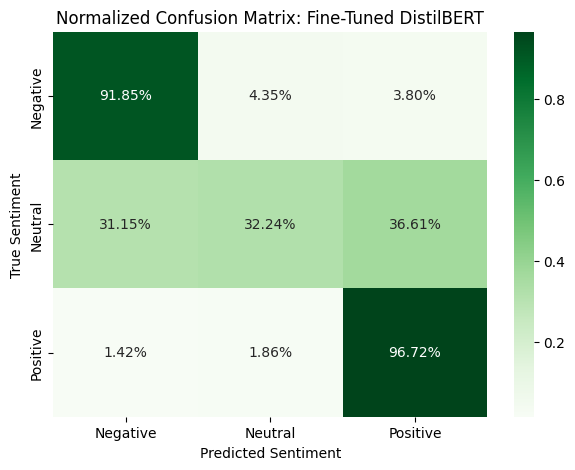

In [8]:
cm = confusion_matrix(y_test, all_preds, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Normalized Confusion Matrix: Fine-Tuned DistilBERT')
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.show()


## 7. DeBERTa-v3 Fine-Tuning & Evaluation (Google Colab GPU)
> **Google Colab Execution:** Fine-tuning `microsoft/deberta-v3-base` requires a GPU (such as a free Google Colab T4). The complete training and evaluation pipeline is provided below.


In [15]:
# DeBERTa-v3 GPU Training (Stabilized FP32 to Prevent Gradient Collapse)
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

DEBERTA_MODEL = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DeBERTa-v3 Execution Device: {device}")

print(f"\n[1/4] Loading {DEBERTA_MODEL} Tokenizer and Model...")
deb_tokenizer = AutoTokenizer.from_pretrained(DEBERTA_MODEL)
deb_model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_MODEL, num_labels=3)
# Force FP32 to prevent DeBERTa-v3 gradient underflow on GPU
deb_model = deb_model.float().to(device)

print("[2/4] Tokenizing Training & Test Sets...")
train_texts = train_df['Review'].fillna('').tolist()
train_labels = train_df['Label'].tolist()
test_texts = test_df['Review'].fillna('').tolist()
test_labels = test_df['Label'].tolist()

train_enc = deb_tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
test_enc = deb_tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')

train_loader = DataLoader(
    TensorDataset(train_enc['input_ids'], train_enc['attention_mask'], torch.tensor(train_labels, dtype=torch.long)),
    batch_size=16,
    shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_enc['input_ids'], test_enc['attention_mask'], torch.tensor(test_labels, dtype=torch.long)),
    batch_size=32,
    shuffle=False
)

# Learning rate 1.5e-5 with warmup prevents collapse
optimizer = AdamW(deb_model.parameters(), lr=1.5e-5, eps=1e-7, weight_decay=0.01)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * 0.15), num_training_steps=total_steps)

print(f"\n[3/4] Training DeBERTa-v3 for {epochs} epochs on {device}...")
deb_model.train()
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for step, batch in enumerate(train_loader):
        b_ids = batch[0].to(device)
        b_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        deb_model.zero_grad()
        outputs = deb_model(input_ids=b_ids, attention_mask=b_mask, labels=b_labels)
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(deb_model.parameters(), 0.5)
        optimizer.step()
        scheduler.step()
        
        if (step + 1) % 100 == 0 or (step + 1) == len(train_loader):
            print(f"  Epoch {epoch}/{epochs} | Step {step+1}/{len(train_loader)} | Batch Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch} Complete | Average Loss: {avg_loss:.4f}\n")

print("[4/4] Evaluating DeBERTa-v3 on Test Set...")
deb_model.eval()
all_deb_preds = []
with torch.no_grad():
    for batch in test_loader:
        b_ids = batch[0].to(device)
        b_mask = batch[1].to(device)
        out = deb_model(input_ids=b_ids, attention_mask=b_mask)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()
        all_deb_preds.extend(preds)

y_test_arr = test_df['Label'].values
deb_acc = accuracy_score(y_test_arr, all_deb_preds)
deb_macro_f1 = f1_score(y_test_arr, all_deb_preds, average='macro')

print(f"\n=== DeBERTa-v3 Test Results ===")
print(f"Accuracy: {deb_acc*100:.2f}%")
print(f"Macro-F1: {deb_macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_arr, all_deb_preds, target_names=['Negative', 'Neutral', 'Positive']))

# Export model checkpoint
SAVE_PATH = os.path.join(MODELS_DIR, 'deberta_sentiment')
os.makedirs(SAVE_PATH, exist_ok=True)
deb_model.save_pretrained(SAVE_PATH)
deb_tokenizer.save_pretrained(SAVE_PATH)
print(f"\n✓ DeBERTa-v3 model checkpoint and tokenizer saved to {SAVE_PATH}")

DeBERTa-v3 Execution Device: cuda

[1/4] Loading microsoft/deberta-v3-base Tokenizer and Model...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

[2/4] Tokenizing Training & Test Sets...

[3/4] Training DeBERTa-v3 for 3 epochs on cuda...
  Epoch 1/3 | Step 100/421 | Batch Loss: 0.7926
  Epoch 1/3 | Step 200/421 | Batch Loss: 0.4020
  Epoch 1/3 | Step 300/421 | Batch Loss: 0.3750
  Epoch 1/3 | Step 400/421 | Batch Loss: 0.1384
  Epoch 1/3 | Step 421/421 | Batch Loss: 0.4681
Epoch 1 Complete | Average Loss: 0.5526

  Epoch 2/3 | Step 100/421 | Batch Loss: 0.4980
  Epoch 2/3 | Step 200/421 | Batch Loss: 0.3426
  Epoch 2/3 | Step 300/421 | Batch Loss: 0.7499
  Epoch 2/3 | Step 400/421 | Batch Loss: 0.3906
  Epoch 2/3 | Step 421/421 | Batch Loss: 0.0679
Epoch 2 Complete | Average Loss: 0.3007

  Epoch 3/3 | Step 100/421 | Batch Loss: 0.3504
  Epoch 3/3 | Step 200/421 | Batch Loss: 0.2740
  Epoch 3/3 | Step 300/421 | Batch Loss: 0.1364
  Epoch 3/3 | Step 400/421 | Batch Loss: 0.0801
  Epoch 3/3 | Step 421/421 | Batch Loss: 0.4208
Epoch 3 Complete | Average Loss: 0.2334

[4/4] Evaluating DeBERTa-v3 on Test Set...

=== DeBERTa-v3 Test R

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ DeBERTa-v3 model checkpoint and tokenizer saved to /content/models/deberta_sentiment
